# Reflection from a Plasma Half-Space with Linear Transition Layer

**Profile:**  εr(z) = −z/δ for z ∈ [−δ, δ],  εr = 1 for z < −δ,  εr = −1 for z > δ

Since εr < 0 in the plasma region, the wave is evanescent for z > δ → **total reflection (|r| = 1)**.
The physically interesting quantity is the **phase of r**, which encodes the depth of penetration into
the plasma and depends on the steepness of the linear transition.

The transition layer is *exactly* linear, so the **Airy-function solution is exact** (TE polarisation).
For TM, the equation has a resonance singularity where εr = 0 (at z = 0 for normal incidence),
so no closed-form Airy solution is available; Dopri5 and FEM P2 are compared instead.

**Visualisation domain:** [−3λ₀, 3λ₀] (L_ext_factor = 2.0 with δ = 1 λ₀)

## Four Studies
1. **Accuracy vs resolution** (δ = λ₀, θ = 45°, TE): L2 relative field error in [−δ,δ] vs cells/λ₀
2. **Phase accuracy vs resolution** (same): |∠r_num − ∠r_Airy| vs cells/λ₀
3. **Phase of r vs incidence angle θ** (δ = λ₀): Airy / Dopri5 / FEM P2 for TE; Dopri5 / FEM P2 for TM
4. **Phase of r vs transition width δ** (θ = 45°): same methods, δ ∈ [0.01, 2] λ₀

In [7]:
import sys, io, contextlib
import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)
try:
    jax.config.update('jax_platform_name', 'gpu')
    _ = jax.devices('gpu')
    print("Using GPU:", jax.devices('gpu'), flush=True)
except RuntimeError:
    jax.config.update('jax_platform_name', 'cpu')
    print("GPU not available, using CPU.", flush=True)

import jax.numpy as jnp

sys.path.insert(0, '/scratch/gpfs/MIKHAILOVA/zl8336/APC523/Final')
sys.path.insert(0, '/scratch/gpfs/MIKHAILOVA/zl8336/APC523/Final/example')
from main import HelmholtzSolver1D, make_kz
from airy_solution import compute_airy_coefficients, airy_field

Using GPU: [CudaDevice(id=0), CudaDevice(id=1)]


In [8]:
# ── Physical parameters ────────────────────────────────────────────────────────
lambda0   = 1.0
k0        = 2.0 * np.pi / lambda0
eps1_val  = 1.0    # left medium (vacuum)
eps2_val  = -1.0   # right medium (plasma)

delta_ref = 1.0 * lambda0   # reference δ for Studies 1, 2, 3
theta_ref = 45.0            # reference angle for Studies 1, 2, 4

# ── Profile factory ───────────────────────────────────────────────────────────
def make_eps_plasma(delta):
    """Return eps_func for profile εr = -z/δ in [-δ,δ], 1 left, -1 right."""
    def eps_func(z):
        z = float(z)
        if z < -delta:
            return 1.0
        if z > delta:
            return -1.0
        return -z / delta
    return eps_func

# ── Airy reference solution (δ=1, θ=45°, TE) ─────────────────────────────────
kx_ref  = k0 * np.sqrt(eps1_val) * np.sin(np.deg2rad(theta_ref))
kz1_ref = make_kz(eps1_val,  float(kx_ref), k0)   # real, propagating
kz2_ref = make_kz(eps2_val,  float(kx_ref), k0)   # purely imaginary, evanescent
g_ref   = -1.0 / delta_ref                         # slope of linear εr

r_airy, t_airy, c1_ref, c2_ref = compute_airy_coefficients(
    0.0, g_ref, -delta_ref, delta_ref, k0, kz1_ref, kz2_ref, kx_ref)

print(f"Airy reference (δ={delta_ref}λ₀, θ={theta_ref}°, TE):")
print(f"  |r| = {abs(r_airy):.10f}  (expected 1)")
print(f"  ∠r  = {np.angle(r_airy)/np.pi:.6f} π  =  {np.degrees(np.angle(r_airy)):.4f}°")
print(f"  kz1 = {kz1_ref:.5g}  (real)")  
print(f"  kz2 = {kz2_ref:.5g}  (imaginary, evanescent)")

# ── Fresnel phase (sharp interface εr=1 → εr=-1) as δ→0 reference ─────────────
def fresnel_r_plasma(theta_deg, pol):
    """Sharp-interface reflection coefficient for εr=1 → εr=-1 interface."""
    kx  = k0 * np.sqrt(eps1_val) * np.sin(np.deg2rad(theta_deg))
    kz1 = make_kz(eps1_val,  float(np.real(kx)), k0)
    kz2 = make_kz(eps2_val,  float(np.real(kx)), k0)
    if pol == 'S':
        return complex((kz1 - kz2) / (kz1 + kz2))
    else:
        return complex((eps2_val*kz1 - eps1_val*kz2) / (eps2_val*kz1 + eps1_val*kz2))

r_f_te = fresnel_r_plasma(theta_ref, 'S')
r_f_tm = fresnel_r_plasma(theta_ref, 'P')
print(f"\nFresnel reference (θ={theta_ref}°):")
print(f"  TE: |r|={abs(r_f_te):.6f}  ∠r={np.angle(r_f_te)/np.pi:.6f}π")
print(f"  TM: |r|={abs(r_f_tm):.6f}  ∠r={np.angle(r_f_tm)/np.pi:.6f}π")

# ── Full-field helper (Airy + plane-wave exteriors) ────────────────────────────
def full_airy_field_plasma(z_arr, delta, k0, kx, r_a, t_a, c1, c2):
    kz1 = make_kz(eps1_val, float(np.real(kx)), k0)
    kz2 = make_kz(eps2_val, float(np.real(kx)), k0)
    z_arr = np.asarray(z_arr, dtype=float)
    field = np.zeros(z_arr.shape, dtype=complex)
    mL = z_arr < -delta
    mT = (z_arr >= -delta) & (z_arr <= delta)
    mR = z_arr > delta
    if mL.any():
        dz = z_arr[mL] + delta
        field[mL] = np.exp(-1j*kz1*dz) + r_a*np.exp(1j*kz1*dz)
    if mT.any():
        field[mT] = airy_field(0.0, -1.0/delta, k0, c1, c2, z_arr[mT], kx)
    if mR.any():
        dz = z_arr[mR] - delta
        field[mR] = t_a * np.exp(-1j*np.conj(kz2)*dz)
    return field

Airy reference (δ=1.0λ₀, θ=45.0°, TE):
  |r| = 1.0000000000  (expected 1)
  ∠r  = -0.461445 π  =  -83.0601°
  kz1 = 4.4429+0j  (real)
  kz2 = 0+7.6953j  (imaginary, evanescent)

Fresnel reference (θ=45.0°):
  TE: |r|=1.000000  ∠r=-0.666667π
  TM: |r|=1.000000  ∠r=0.666667π


## Studies 1 & 2: Convergence with Resolution (δ = λ₀, θ = 45°, TE)

In [9]:
res_list    = np.logspace(2,10, num=9,endpoint=True,base=2)   # cells per λ₀ in transition layer
z_common    = np.linspace(-delta_ref, delta_ref, 600)  # common evaluation grid
field_airy_ref = airy_field(0.0, g_ref, k0, c1_ref, c2_ref, z_common, kx_ref)
norm_airy   = np.sqrt(np.mean(np.abs(field_airy_ref)**2))

method_keys    = ['heun', 'ode5', 'fem1', 'fem2']
method_labels  = ['ODE Heun (fixed)', 'ODE Dopri5', 'FEM P1', 'FEM P2']
method_colors  = ['C1', 'C2', 'C3', 'C4']
method_markers = ['o', 's', '^', 'D']

l2_errors    = {k: [] for k in method_keys}
phase_errors = {k: [] for k in method_keys}
# Also store full results at a representative resolution for field plots
RES_PLOT = 32
results_plot = {}

eps_ref = make_eps_plasma(delta_ref)
with contextlib.redirect_stdout(io.StringIO()):
    solver_ref = HelmholtzSolver1D(
        eps_ref, -delta_ref, delta_ref, theta_deg=theta_ref, pol='S', lambda0=lambda0)

for res in res_list:
    with contextlib.redirect_stdout(io.StringIO()):
        res_f = float(res)
        r_heun = solver_ref.solve_ode(res_trans=res_f, fixed_step=True,  solver_name='Heun')
        r_ode5 = solver_ref.solve_ode(res_trans=res_f, fixed_step=False)
        r_fem1 = solver_ref.solve_fem(res_trans=res_f, order=1)
        r_fem2 = solver_ref.solve_fem(res_trans=res_f, order=2)

    all_res = {'heun': r_heun, 'ode5': r_ode5, 'fem1': r_fem1, 'fem2': r_fem2}

    if res == RES_PLOT:
        results_plot = all_res

    for key in method_keys:
        z_num = np.array(all_res[key]['z'])
        f_num = np.array(all_res[key]['field'])
        # Restrict to transition layer
        mask  = (z_num >= -delta_ref - 1e-10) & (z_num <= delta_ref + 1e-10)
        z_in  = z_num[mask]
        f_in  = f_num[mask]
        # Interpolate to common grid
        f_int = (np.interp(z_common, z_in, f_in.real)
                 + 1j * np.interp(z_common, z_in, f_in.imag))
        # L2 relative error
        l2_errors[key].append(
            np.sqrt(np.mean(np.abs(f_int - field_airy_ref)**2)) / norm_airy)
        # Phase error in r
        phase_errors[key].append(
            abs(np.angle(all_res[key]['r']) - np.angle(r_airy)))

    print(f"res={res}: L2 Heun={l2_errors['heun'][-1]}  "
          f"Dopri5={l2_errors['ode5'][-1]}  "
          f"P1={l2_errors['fem1'][-1]}  "
          f"P2={l2_errors['fem2'][-1]}", flush=True)

res=4.0: L2 Heun=0.1453727255132854  Dopri5=0.04942493386119458  P1=0.3209672065582657  P2=0.028632836670886775
res=8.0: L2 Heun=0.0603992355723798  Dopri5=0.01784345504018091  P1=0.27373554264113914  P2=0.012372867061646515
res=16.0: L2 Heun=0.015244220602975683  Dopri5=0.004183973718556564  P1=0.11114467599698362  P2=0.0026052035890222376
res=32.0: L2 Heun=0.0037786504962225463  Dopri5=0.0010134293965765979  P1=0.028788622592978555  P2=0.0005342987856785664
res=64.0: L2 Heun=0.0009377603673918984  Dopri5=0.00024940651487614094  P1=0.0072574368714182665  P2=0.0001254064066677836
res=128.0: L2 Heun=0.00023338695432575916  Dopri5=6.186490947134505e-05  P1=0.0018177577157519778  P2=3.0726837203802686e-05
res=256.0: L2 Heun=5.820387938627653e-05  Dopri5=1.5406003380253313e-05  P1=0.0004546051485517438  P2=7.627938107676803e-06
res=512.0: L2 Heun=1.4532627982763092e-05  Dopri5=3.842945615274885e-06  P1=0.000113655770672679  P2=1.9017386156798792e-06
res=1024.0: L2 Heun=3.630651575991344e-0

### Study 1: Field profiles at res = 32 cells/λ₀

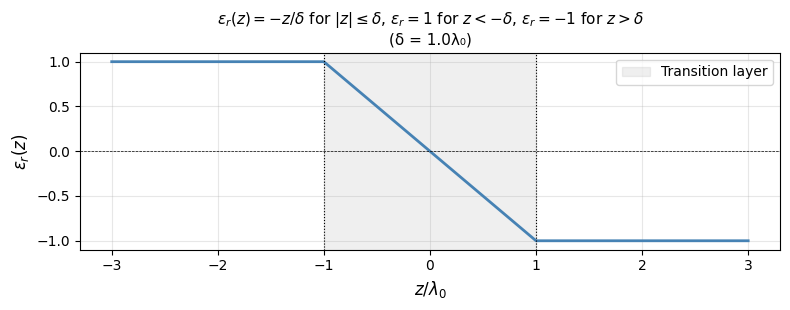

In [10]:
z_vis = np.linspace(-3.0*lambda0, 3.0*lambda0, 1200)
eps_vis = np.array([make_eps_plasma(delta_ref)(float(z)) for z in z_vis])

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(z_vis / lambda0, np.real(eps_vis), color='steelblue', lw=2)
ax.axvspan(-delta_ref / lambda0, delta_ref / lambda0, color='gray', alpha=0.12, label='Transition layer')
ax.axvline(-delta_ref / lambda0, color='k', lw=0.8, ls=':')
ax.axvline( delta_ref / lambda0, color='k', lw=0.8, ls=':')
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel(r'$z / \lambda_0$', fontsize=12)
ax.set_ylabel(r'$\varepsilon_r(z)$', fontsize=12)
ax.set_title(
    r'$\varepsilon_r(z) = -z/\delta$ for $|z|\leq\delta$, '
    r'$\varepsilon_r=1$ for $z<-\delta$, $\varepsilon_r=-1$ for $z>\delta$'
    f'\n(δ = {delta_ref}λ₀)',
    fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plasma_eps_profile.png', dpi=150, bbox_inches='tight')
plt.show()

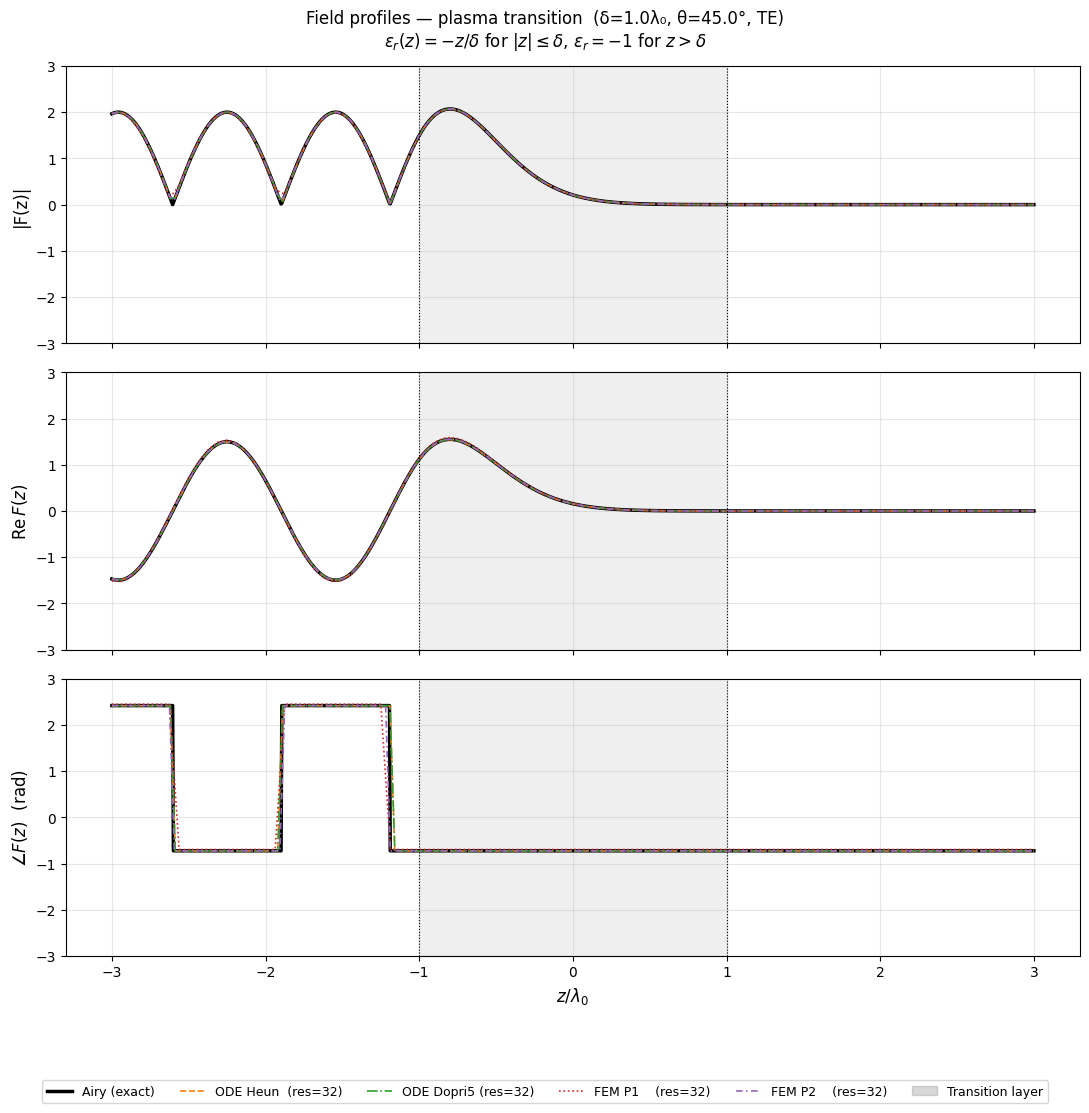

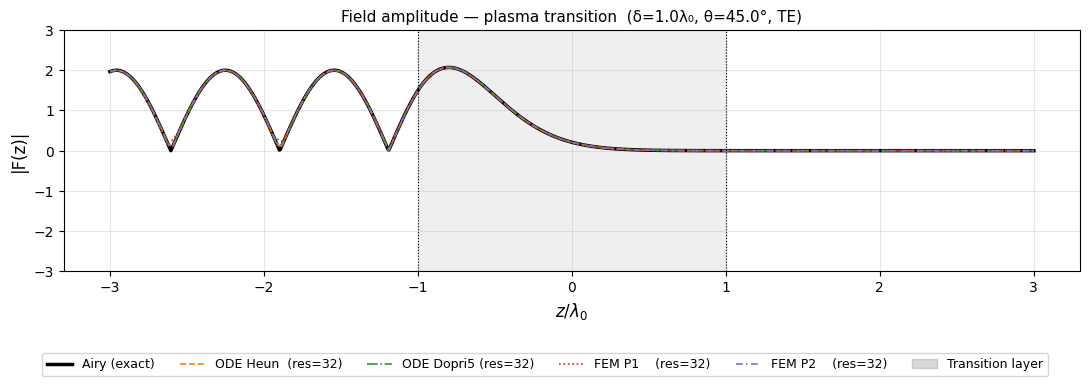

Saved plasma_field_abs.png


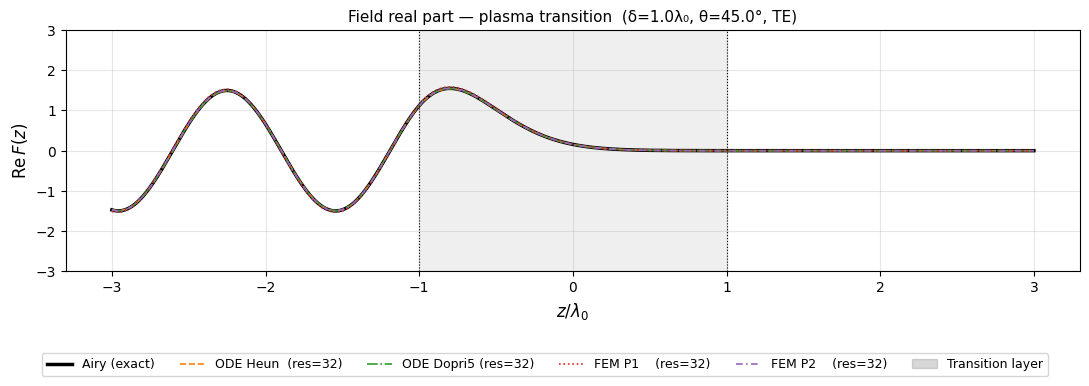

Saved plasma_field_real.png


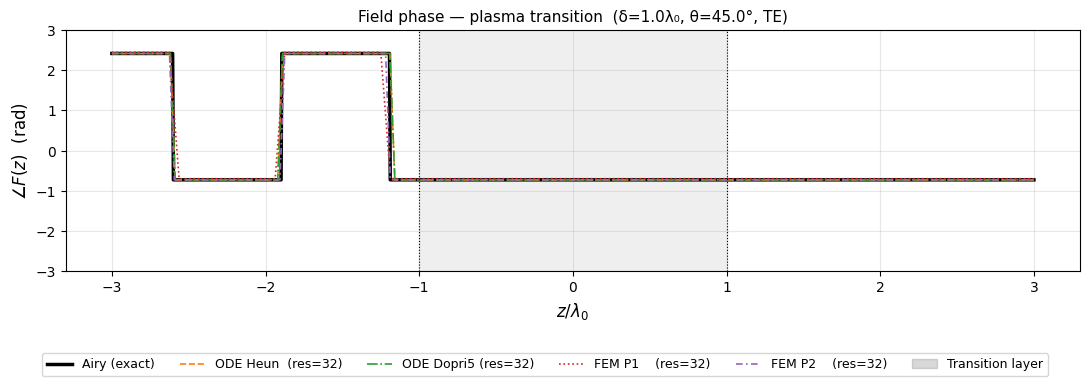

Saved plasma_field_angle.png


In [11]:
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# ── Construct Airy full field on the visualisation domain ─────────────────────
z_vis = np.linspace(-3.0*lambda0, 3.0*lambda0, 1200)
field_airy_vis = full_airy_field_plasma(
    z_vis, delta_ref, k0, kx_ref, r_airy, t_airy, c1_ref, c2_ref)

airy_style = dict(color='k', lw=2.5, ls='-',  label='Airy (exact)')
styles = {
    'heun': dict(color='C1', lw=1.2, ls='--',            label=f'ODE Heun  (res={RES_PLOT})'),
    'ode5': dict(color='C2', lw=1.2, ls='-.',            label=f'ODE Dopri5 (res={RES_PLOT})'),
    'fem1': dict(color='C3', lw=1.2, ls=':',             label=f'FEM P1    (res={RES_PLOT})'),
    'fem2': dict(color='C4', lw=1.2, ls=(0,(4,2,1,2)),  label=f'FEM P2    (res={RES_PLOT})'),
}

quantities = [
    (np.abs,   '|F(z)|',                 'amplitude', 'plasma_field_abs.png'),
    (np.real,  r'$\mathrm{Re}\,F(z)$',   'real part', 'plasma_field_real.png'),
    (np.angle, r'$\angle F(z)$  (rad)',   'phase',     'plasma_field_angle.png'),
]

# ── Combined 3-panel figure (overview) ───────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=True)
for ax, (func, ylabel, _, __) in zip(axes, quantities):
    ax.plot(z_vis, func(field_airy_vis), **airy_style)
    for key in method_keys:
        z_n = np.array(results_plot[key]['z'])
        f_n = np.array(results_plot[key]['field'])
        ax.plot(z_n, func(f_n), **styles[key])
    ax.axvspan(-delta_ref, delta_ref, color='gray', alpha=0.12)
    ax.axvline(-delta_ref, color='k', lw=0.8, ls=':')
    ax.axvline( delta_ref, color='k', lw=0.8, ls=':')
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_ylim(-3, 3)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel(r'$z / \lambda_0$', fontsize=12)
fig.suptitle(
    f'Field profiles — plasma transition  (δ={delta_ref}λ₀, θ={theta_ref}°, TE)\n'
    r'$\varepsilon_r(z) = -z/\delta$ for $|z|\leq\delta$, '
    r'$\varepsilon_r = -1$ for $z > \delta$',
    fontsize=12)
handles = [Line2D([0],[0], **airy_style)]
handles += [Line2D([0],[0], color=styles[k]['color'], ls=styles[k]['ls'],
                   lw=styles[k]['lw'], label=styles[k]['label']) for k in method_keys]
handles += [mpatches.Patch(color='gray', alpha=0.3, label='Transition layer')]
fig.legend(handles=handles, loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.02), fontsize=9)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('plasma_field_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Individual single-panel figures ──────────────────────────────────────────
for func, ylabel, title_suffix, fname in quantities:
    fig_s, ax_s = plt.subplots(figsize=(11, 3.8))
    ax_s.plot(z_vis, func(field_airy_vis), **airy_style)
    for key in method_keys:
        z_n = np.array(results_plot[key]['z'])
        f_n = np.array(results_plot[key]['field'])
        ax_s.plot(z_n, func(f_n), **styles[key])
    ax_s.axvspan(-delta_ref, delta_ref, color='gray', alpha=0.12)
    ax_s.axvline(-delta_ref, color='k', lw=0.8, ls=':')
    ax_s.axvline( delta_ref, color='k', lw=0.8, ls=':')
    ax_s.set_xlabel(r'$z / \lambda_0$', fontsize=12)
    ax_s.set_ylabel(ylabel, fontsize=12)
    ax_s.set_ylim(-3, 3)
    ax_s.set_title(
        f'Field {title_suffix} — plasma transition'
        f'  (δ={delta_ref}λ₀, θ={theta_ref}°, TE)',
        fontsize=11)
    ax_s.grid(True, alpha=0.3)
    handles_s = [Line2D([0],[0], **airy_style)]
    handles_s += [Line2D([0],[0], color=styles[k]['color'], ls=styles[k]['ls'],
                         lw=styles[k]['lw'], label=styles[k]['label']) for k in method_keys]
    handles_s += [mpatches.Patch(color='gray', alpha=0.3, label='Transition layer')]
    fig_s.legend(handles=handles_s, loc='lower center', ncol=6,
                 bbox_to_anchor=(0.5, -0.02), fontsize=9)
    plt.tight_layout(rect=[0, 0.10, 1, 1])
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')

### Studies 1 & 2: Convergence plots

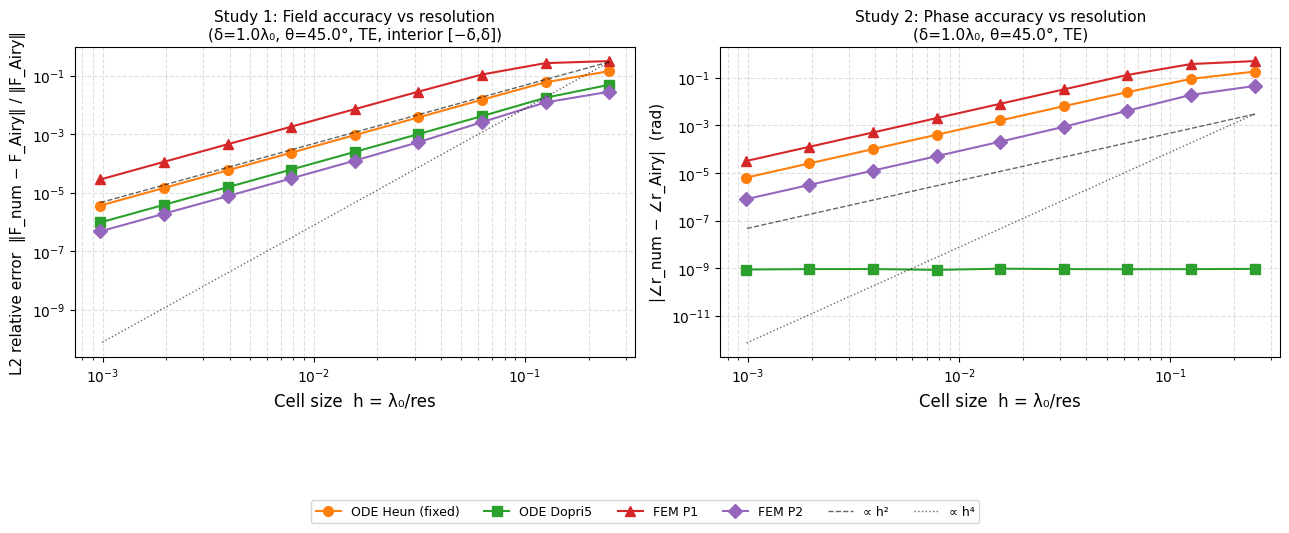

In [12]:
from matplotlib.lines import Line2D

h_vals = np.array([lambda0 / r for r in res_list])   # cell size h = λ₀ / res
h_ref  = np.array([h_vals[0], h_vals[-1]])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: L2 field error ──────────────────────────────────────────────────────
ax = axes[0]
for key, label, color, marker in zip(method_keys, method_labels, method_colors, method_markers):
    err = np.array(l2_errors[key])
    ax.loglog(h_vals, err, marker=marker, color=color, lw=1.5, ms=7)

ax.loglog(h_ref, 0.3 * (h_ref/h_ref[0])**2, 'k--', lw=1, alpha=0.6)
ax.loglog(h_ref, 0.3 * (h_ref/h_ref[0])**4, 'k:',  lw=1, alpha=0.6)

ax.set_xlabel('Cell size  h = λ₀/res', fontsize=12)
ax.set_ylabel('L2 relative error  ‖F_num − F_Airy‖ / ‖F_Airy‖', fontsize=11)
ax.set_title('Study 1: Field accuracy vs resolution\n'
             f'(δ={delta_ref}λ₀, θ={theta_ref}°, TE, interior [−δ,δ])', fontsize=11)
ax.grid(True, which='both', ls='--', alpha=0.4)

# ── Right: Phase error in r ───────────────────────────────────────────────────
ax = axes[1]
for key, label, color, marker in zip(method_keys, method_labels, method_colors, method_markers):
    err = np.array(phase_errors[key])
    err = np.where(err < 1e-15, 1e-15, err)   # floor at float noise
    ax.loglog(h_vals, err, marker=marker, color=color, lw=1.5, ms=7)

ax.loglog(h_ref, 3e-3 * (h_ref/h_ref[0])**2, 'k--', lw=1, alpha=0.6)
ax.loglog(h_ref, 3e-3 * (h_ref/h_ref[0])**4, 'k:',  lw=1, alpha=0.6)

ax.set_xlabel('Cell size  h = λ₀/res', fontsize=12)
ax.set_ylabel('|∠r_num − ∠r_Airy|  (rad)', fontsize=11)
ax.set_title('Study 2: Phase accuracy vs resolution\n'
             f'(δ={delta_ref}λ₀, θ={theta_ref}°, TE)', fontsize=11)
ax.grid(True, which='both', ls='--', alpha=0.4)

handles = [Line2D([0],[0], marker=m, color=c, lw=1.5, ms=7, label=l)
           for l, c, m in zip(method_labels, method_colors, method_markers)]
handles += [Line2D([0],[0], color='k', ls='--', lw=1, alpha=0.6, label='∝ h²'),
            Line2D([0],[0], color='k', ls=':',  lw=1, alpha=0.6, label='∝ h⁴')]
fig.legend(handles=handles, loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.07), fontsize=9)
plt.tight_layout(rect=[0, 0.14, 1, 1])
plt.savefig('plasma_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## Study 3: Phase of r vs Incidence Angle θ  (δ = λ₀)

TE: Airy exact + Dopri5 + FEM P2.  TM: Dopri5 + FEM P2 (no closed-form Airy for TM;
note the εr = 0 plasma resonance at z = 0 makes TM numerically challenging near θ = 0).

In [13]:
from main import build_interp_arrays, sweep_ode, sweep_fem

theta_arr = np.linspace(0.0, 85.0, 70)

N_INTERP_3 = 4000
N_TRANS_3  = 500   # ODE step hint

# ── Pre-build ε arrays once (profile fixed, delta=delta_ref) ─────────────────
eps_d1 = make_eps_plasma(delta_ref)
z_grid3, eps3, deps3 = build_interp_arrays(eps_d1, -delta_ref, delta_ref, n=N_INTERP_3)

# ── kx / kz1 / kz2 for all angles ────────────────────────────────────────────
kx_arr3  = jnp.array([k0 * np.sqrt(eps1_val) * np.sin(np.deg2rad(th)) for th in theta_arr])
kz1_arr3 = jnp.array([make_kz(eps1_val, float(kx), k0) for kx in np.array(kx_arr3)],
                      dtype=jnp.complex128)
kz2_arr3 = jnp.array([make_kz(eps2_val, float(np.real(kx)), k0) for kx in np.array(kx_arr3)],
                      dtype=jnp.complex128)

N_TH = len(theta_arr)

# ── ODE interpolation arrays (tiled for sweep_ode) ───────────────────────────
eps_re_b  = jnp.tile(jnp.real(eps3 )[None, :], (N_TH, 1))
eps_im_b  = jnp.tile(jnp.imag(eps3 )[None, :], (N_TH, 1))
deps_re_b = jnp.tile(jnp.real(deps3)[None, :], (N_TH, 1))
deps_im_b = jnp.tile(jnp.imag(deps3)[None, :], (N_TH, 1))

# ── FEM mesh matching default auto-resolution for this profile ────────────────
# auto_res_trans = 100 × max|ε|=1 → 100/λ0;  n_trans = ceil(100 × 2δ) = 200
# auto_res_ext   = 50  × max(1,1) → 50/λ0;   L_ext=2λ0, n_ext = ceil(50×2) = 100
n_fem_trans = max(10, int(np.ceil(100.0 * 2.0 * delta_ref / lambda0)))
n_fem_ext   = max(10, int(np.ceil(50.0  * 2.0 * lambda0   / lambda0)))
L_ext3      = 2.0 * lambda0

z_ext_l3 = jnp.linspace(-delta_ref - L_ext3, -delta_ref, n_fem_ext, endpoint=False)
z_trans3  = jnp.linspace(-delta_ref,           delta_ref, n_fem_trans)
z_ext_r3  = jnp.linspace( delta_ref,  delta_ref + L_ext3, n_fem_ext + 1)[1:]
nodes3    = jnp.concatenate([z_ext_l3, z_trans3, z_ext_r3])

eps_trans3 = jnp.array([complex(eps_d1(float(z))) for z in z_trans3], dtype=jnp.complex128)
eps_nodes3 = jnp.concatenate([
    jnp.full(n_fem_ext, complex(eps1_val), dtype=jnp.complex128),
    eps_trans3,
    jnp.full(n_fem_ext, complex(eps2_val), dtype=jnp.complex128),
])
eps_nodes3_b = jnp.tile(eps_nodes3[None, :], (N_TH, 1))   # (N_TH, n_nodes)

print(f"FEM mesh: n_ext={n_fem_ext}, n_trans={n_fem_trans}, total={nodes3.shape[0]} nodes", flush=True)

# ── Airy reference (TE): analytical loop ─────────────────────────────────────
phase_te_airy = np.array([
    np.angle(compute_airy_coefficients(
        0.0, -1.0/delta_ref, -delta_ref, delta_ref, k0,
        make_kz(eps1_val, float(kx), k0),
        make_kz(eps2_val, float(np.real(kx)), k0), float(kx))[0])
    for kx in np.array(kx_arr3)])

# ── ODE Dopri5: TE and TM in parallel via sweep_ode ──────────────────────────
# return_field=True → complex field (N, n_trans), field[:,0] = 1 + r
print("ODE TE sweep ...", flush=True)
field_te3 = sweep_ode(
    kx_arr3, kz1_arr3, kz2_arr3,
    eps_re_b, eps_im_b, deps_re_b, deps_im_b,
    z_grid3, float(k0), float(-delta_ref), float(delta_ref), N_TRANS_3, 'S',
    return_field=True,
)
phase_te_ode5 = np.angle(np.array(field_te3[:, 0]) - 1.0)

print("ODE TM sweep ...", flush=True)
field_tm3 = sweep_ode(
    kx_arr3, kz1_arr3, kz2_arr3,
    eps_re_b, eps_im_b, deps_re_b, deps_im_b,
    z_grid3, float(k0), float(-delta_ref), float(delta_ref), N_TRANS_3, 'P',
    return_field=True,
)
phase_tm_ode5 = np.angle(np.array(field_tm3[:, 0]) - 1.0)
print("ODE sweeps done.", flush=True)

# ── FEM P2: TE and TM in parallel via sweep_fem ──────────────────────────────
# return_field=True → complex r (N,)
print("FEM P2 TE sweep ...", flush=True)
r_te_fem2 = np.array(sweep_fem(
    kx_arr3, kz1_arr3, kz2_arr3, eps_nodes3_b,
    nodes3, float(k0), complex(eps1_val), complex(eps2_val), n_fem_ext, 'S', order=2,
    return_field=True,
))
phase_te_fem2 = np.angle(r_te_fem2)

print("FEM P2 TM sweep ...", flush=True)
r_tm_fem2 = np.array(sweep_fem(
    kx_arr3, kz1_arr3, kz2_arr3, eps_nodes3_b,
    nodes3, float(k0), complex(eps1_val), complex(eps2_val), n_fem_ext, 'P', order=2,
    return_field=True,
))
phase_tm_fem2 = np.angle(r_tm_fem2)
print("FEM sweeps done.", flush=True)

# ── Unwrap for smooth plots ───────────────────────────────────────────────────
phase_te_airy = np.unwrap(phase_te_airy)
phase_te_ode5 = np.unwrap(phase_te_ode5)
phase_te_fem2 = np.unwrap(phase_te_fem2)
phase_tm_ode5 = np.unwrap(phase_tm_ode5)
phase_tm_fem2 = np.unwrap(phase_tm_fem2)

FEM mesh: n_ext=100, n_trans=200, total=400 nodes
ODE TE sweep ...
ODE TM sweep ...
ODE sweeps done.
FEM P2 TE sweep ...
FEM P2 TM sweep ...
FEM sweeps done.


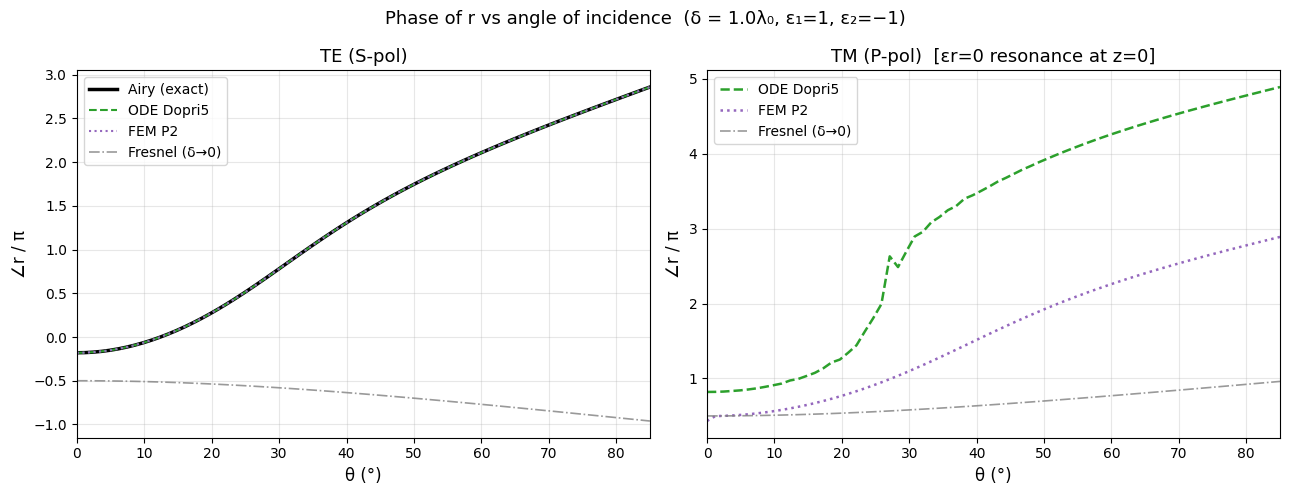

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

# TE
ax = axes[0]
ax.plot(theta_arr, phase_te_airy/np.pi, 'k-',  lw=2.5, label='Airy (exact)')
ax.plot(theta_arr, phase_te_ode5/np.pi, 'C2--', lw=1.5, label='ODE Dopri5')
ax.plot(theta_arr, phase_te_fem2/np.pi, 'C4:',  lw=1.5, label='FEM P2')

# Fresnel reference (δ → 0 limit)
r_f_te_arr = [fresnel_r_plasma(th, 'S') for th in theta_arr]
ax.plot(theta_arr, np.unwrap(np.angle(r_f_te_arr))/np.pi,
        color='gray', lw=1.2, ls='-.', alpha=0.8, label='Fresnel (δ→0)')

ax.set_xlabel('θ (°)', fontsize=12)
ax.set_ylabel('∠r / π', fontsize=12)
ax.set_title('TE (S-pol)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 85)

# TM
ax = axes[1]
ax.plot(theta_arr, phase_tm_ode5/np.pi, 'C2--', lw=1.8, label='ODE Dopri5')
ax.plot(theta_arr, phase_tm_fem2/np.pi, 'C4:',  lw=1.8, label='FEM P2')

r_f_tm_arr = [fresnel_r_plasma(th, 'P') for th in theta_arr]
ax.plot(theta_arr, np.unwrap(np.angle(r_f_tm_arr))/np.pi,
        color='gray', lw=1.2, ls='-.', alpha=0.8, label='Fresnel (δ→0)')

ax.set_xlabel('θ (°)', fontsize=12)
ax.set_ylabel('∠r / π', fontsize=12)
ax.set_title('TM (P-pol)  [εr=0 resonance at z=0]', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 85)

fig.suptitle(
    f'Phase of r vs angle of incidence  (δ = {delta_ref}λ₀, ε₁=1, ε₂=−1)',
    fontsize=13)
plt.tight_layout()
plt.savefig('plasma_phase_vs_theta.png', dpi=150, bbox_inches='tight')
plt.show()

## Study 4: Phase of r vs Transition Width δ  (θ = 45°)

As δ → 0 the profile approaches a sharp εr=1/εr=−1 interface → phase converges to the Fresnel value.
As δ → ∞ the transition becomes gentler and the reflection phase changes smoothly.

In [15]:
delta_arr = np.logspace(-2, np.log10(2.0), 25)   # 0.01 … 2.0, log-spaced

kx_45  = k0 * np.sqrt(eps1_val) * np.sin(np.deg2rad(theta_ref))
kz1_45 = make_kz(eps1_val, float(kx_45), k0)
kz2_45 = make_kz(eps2_val, float(kx_45), k0)

phase_te_airy_d = []
phase_te_ode5_d = []
phase_te_fem2_d = []
phase_tm_ode5_d = []
phase_tm_fem2_d = []

for delta in delta_arr:
    delta = float(delta)
    # Airy (TE)
    r_a, *_ = compute_airy_coefficients(
        0.0, -1.0/delta, -delta, delta, k0, kz1_45, kz2_45, kx_45)
    phase_te_airy_d.append(np.angle(r_a))

    eps_d = make_eps_plasma(delta)
    with contextlib.redirect_stdout(io.StringIO()):
        sv_te = HelmholtzSolver1D(
            eps_d, -delta, delta, theta_deg=theta_ref, pol='S', lambda0=lambda0)
        sv_tm = HelmholtzSolver1D(
            eps_d, -delta, delta, theta_deg=theta_ref, pol='P', lambda0=lambda0)
        phase_te_ode5_d.append(np.angle(sv_te.solve_ode()['r']))
        phase_te_fem2_d.append(np.angle(sv_te.solve_fem(order=2)['r']))
        phase_tm_ode5_d.append(np.angle(sv_tm.solve_ode()['r']))
        phase_tm_fem2_d.append(np.angle(sv_tm.solve_fem(order=2)['r']))

print("Study 4 done.", flush=True)

# Unwrap
phase_te_airy_d = np.unwrap(phase_te_airy_d)
phase_te_ode5_d = np.unwrap(phase_te_ode5_d)
phase_te_fem2_d = np.unwrap(phase_te_fem2_d)
phase_tm_ode5_d = np.unwrap(phase_tm_ode5_d)
phase_tm_fem2_d = np.unwrap(phase_tm_fem2_d)

Study 4 done.


[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan]


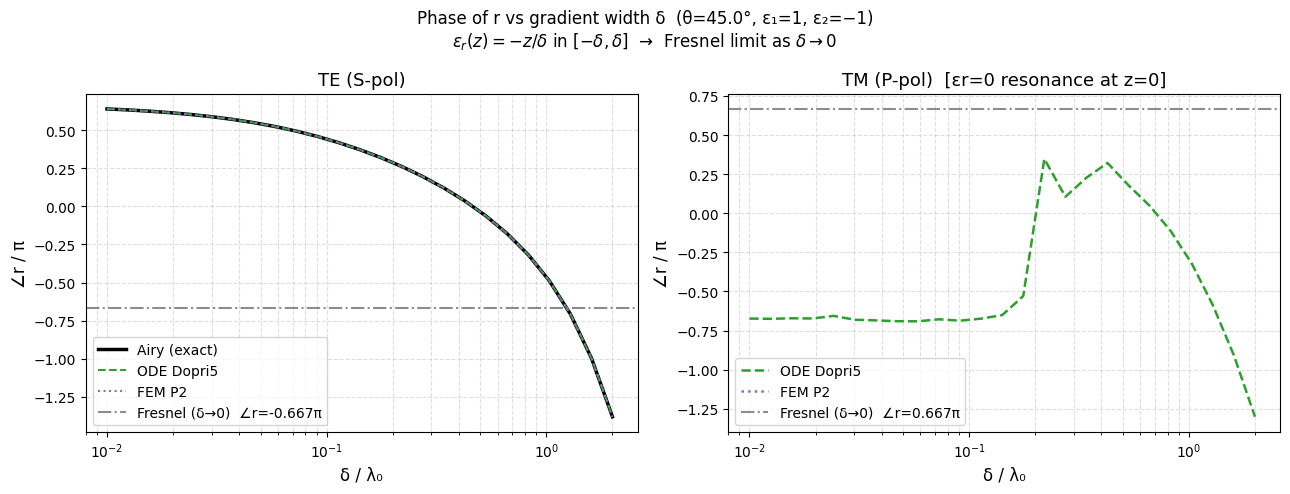

: 

In [ ]:
r_f_te = fresnel_r_plasma(theta_ref, 'S')
r_f_tm = fresnel_r_plasma(theta_ref, 'P')

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

# TE
ax = axes[0]
ax.semilogx(delta_arr, phase_te_airy_d/np.pi, 'k-',  lw=2.5, label='Airy (exact)')
ax.semilogx(delta_arr, phase_te_ode5_d/np.pi, 'C2--', lw=1.5, label='ODE Dopri5')
ax.semilogx(delta_arr, phase_te_fem2_d/np.pi, 'C4:',  lw=1.5, label='FEM P2')
ax.axhline(np.angle(r_f_te)/np.pi, color='gray', ls='-.', lw=1.5, alpha=0.9,
           label=f'Fresnel (δ→0)  ∠r={np.angle(r_f_te)/np.pi:.3f}π')

ax.set_xlabel('δ / λ₀', fontsize=12)
ax.set_ylabel('∠r / π', fontsize=12)
ax.set_title('TE (S-pol)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which='both', ls='--', alpha=0.4)
ax.set_xlim(delta_arr[0]*0.8, delta_arr[-1]*1.3)

# TM
ax = axes[1]
ax.semilogx(delta_arr, phase_tm_ode5_d/np.pi, 'C2--', lw=1.8, label='ODE Dopri5')
ax.semilogx(delta_arr, phase_tm_fem2_d/np.pi, 'C4:',  lw=1.8, label='FEM P2')
ax.axhline(np.angle(r_f_tm)/np.pi, color='gray', ls='-.', lw=1.5, alpha=0.9,
           label=f'Fresnel (δ→0)  ∠r={np.angle(r_f_tm)/np.pi:.3f}π')
print(phase_tm_fem2_d)
ax.set_xlabel('δ / λ₀', fontsize=12)
ax.set_ylabel('∠r / π', fontsize=12)
ax.set_title('TM (P-pol)  [εr=0 resonance at z=0]', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which='both', ls='--', alpha=0.4)
ax.set_xlim(delta_arr[0]*0.8, delta_arr[-1]*1.3)

fig.suptitle(
    f'Phase of r vs gradient width δ  (θ={theta_ref}°, ε₁=1, ε₂=−1)\n'
    r'$\varepsilon_r(z)=-z/\delta$ in $[-\delta,\delta]$  →  Fresnel limit as $\delta\to 0$',
    fontsize=12)
plt.tight_layout()
plt.savefig('plasma_phase_vs_delta.png', dpi=150, bbox_inches='tight')
plt.show()